In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [20]:
sensor_data_cols = ["Time(s)","I_LOAD", "P_H2", "P_AIR", "T_H2O_IN", "T_H2O_OUT", "T_H2O_MEAN", "R"]
polacurve_sets = {}
hfr_sets = {}
sensor_sets = {}
for key_T in ["T50", "T60", "T70"]:
    for key_P in ["P300", "P400", "P500"]:
        if key_P == "P300":
            for key_HRC in ["0", "50"]:
                polacurve_sets[f"{key_T}_{key_P}_HRC{key_HRC}"] = []
                sensor_sets[f"{key_T}_{key_P}_HRC{key_HRC}"] = []
                hfr_sets[f"{key_T}_{key_P}_HRC{key_HRC}"] = []
        else:
            polacurve_sets[f"{key_T}_{key_P}_HRC50"] = []
            sensor_sets[f"{key_T}_{key_P}_HRC50"] = []
            hfr_sets[f"{key_T}_{key_P}_HRC50"] = []

In [21]:
filenames = ["SYNTH_T50_N1.xlsx", "SYNTH_T60_N1.xlsx", "SYNTH_T70_N1.xlsx"]
for fname in filenames:
    workbook_sheets = pd.read_excel(fname, sheet_name=None)
    for sheet_name, record in workbook_sheets.items():
        if "REC" in sheet_name:
            Tstr = fname.split("_")[1]
            Pa = round(np.mean(record["P_H2"]),-2)
            Pc = round(np.mean(record["P_AIR"]),-2)
            if np.mean(record["HR_AIR_FC"]) < 25:
                HRC = 0
            else:
                HRC = 50
            polacurve_sets[f"{Tstr}_P{int(Pa)}_HRC{HRC}"].append((np.mean(record["VFC"]), np.mean(record["I_LOAD"])))
            sensor_sets[f"{Tstr}_P{int(Pa)}_HRC{HRC}"].append(record[sensor_data_cols])
            hfr_sets[f"{Tstr}_P{int(Pa)}_HRC{HRC}"].append((np.mean(record["R"]), np.mean(record["I_LOAD"])))

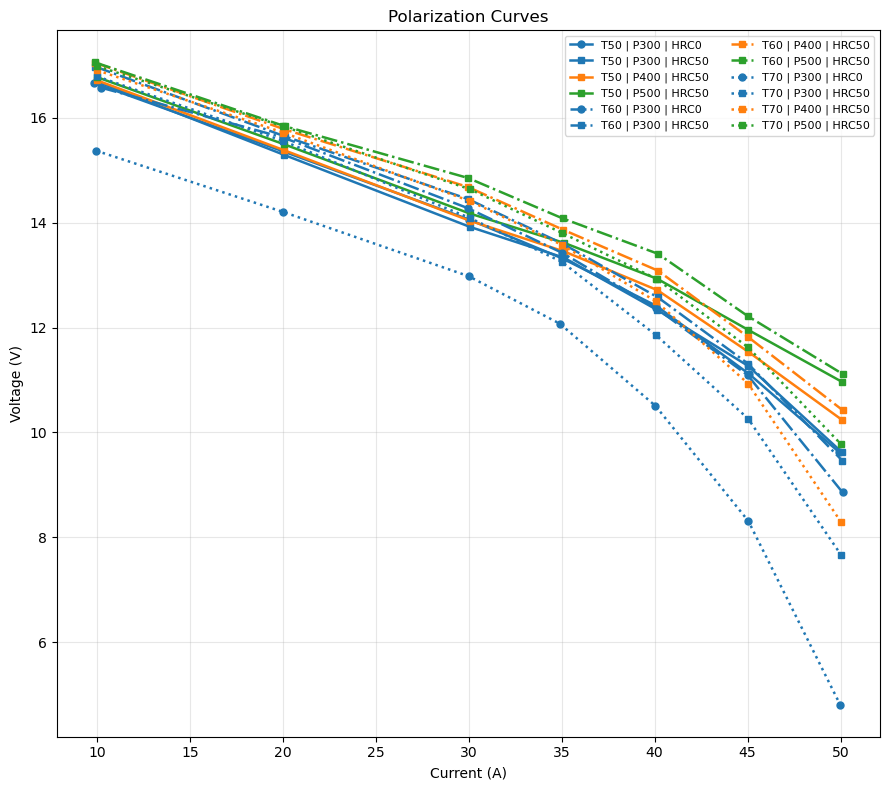

In [22]:
plt.figure(figsize=(9, 8))

temp_linestyles = {"T50": "-", "T60": "-.", "T70": ":"}
pressure_colors = {"P300": "tab:blue", "P400": "tab:orange", "P500": "tab:green"}
hrc_markers = {"HRC0": "o", "HRC50": "s"}

for key, pola_data in polacurve_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    plt.plot(df["I_LOAD"],df["VFC"], linestyle=temp_linestyles.get(key_T, "-"),color=pressure_colors.get(key_P, "black"),
        marker=hrc_markers.get(key_HRC, "o"), linewidth=1.8,markersize=5,label=f"{key_T} | {key_P} | {key_HRC}")

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

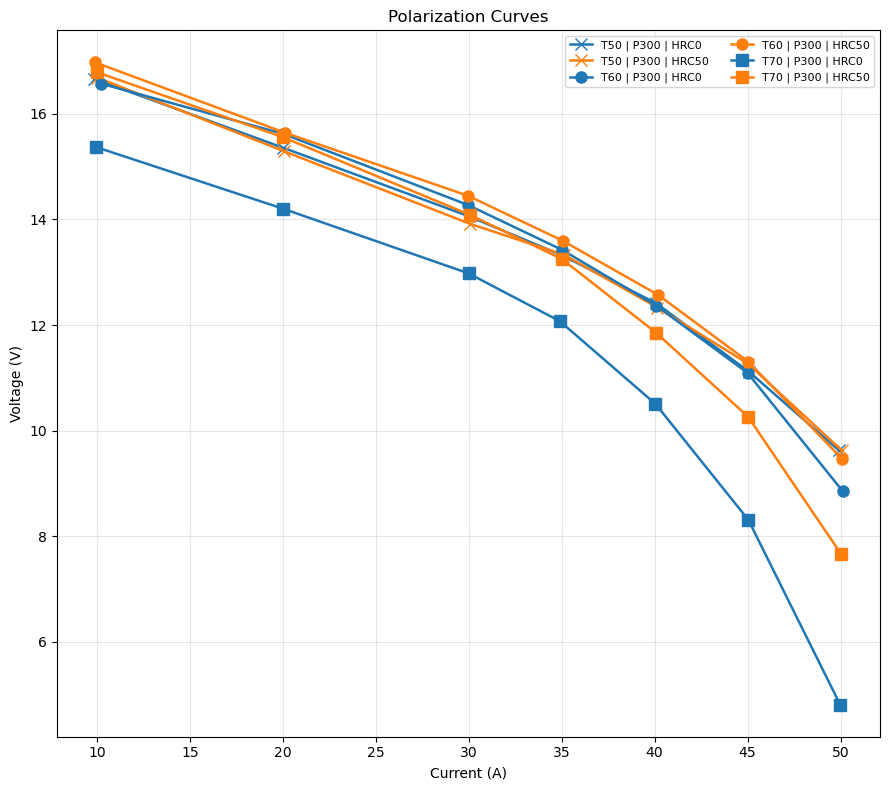

In [23]:
plt.figure(figsize=(9, 8))

T_marker = {"T50": "x", "T60": "o", "T70": "s"}
hrc_color = {"HRC0": "tab:blue", "HRC50": "tab:orange"}

for key, pola_data in polacurve_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    if (key_HRC == "HRC0" and key_P == "P300") or (key_HRC == "HRC50" and key_P == "P300"):
        df = pd.DataFrame(pola_data, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
        plt.plot(df["I_LOAD"],df["VFC"], linestyle="-",color=hrc_color.get(key_HRC, "black"),
                    marker=T_marker.get(key_T, "o"), linewidth=1.8,markersize=8,label=f"{key_T} | {key_P} | {key_HRC}")

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

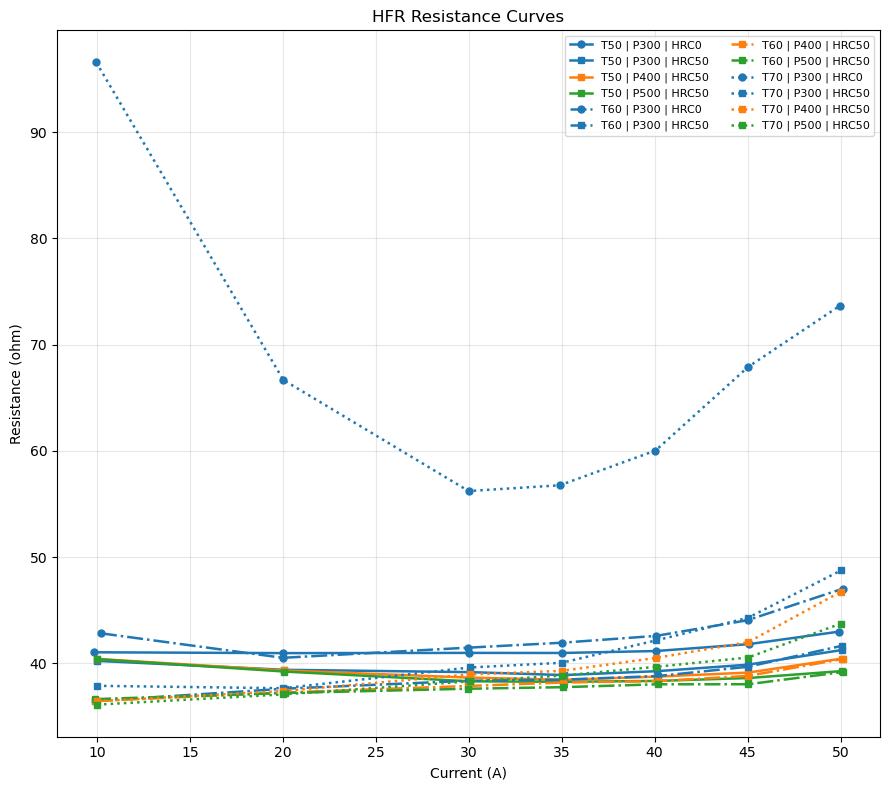

In [24]:
plt.figure(figsize=(9, 8))

for key, pola_data in hfr_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["R", "I_LOAD"]).sort_values("I_LOAD")

    plt.plot(df["I_LOAD"],df["R"],linestyle=temp_linestyles.get(key_T, "-"),color=pressure_colors.get(key_P, "black"),
        marker=hrc_markers.get(key_HRC, "o"),linewidth=1.8,markersize=5,label=f"{key_T} | {key_P} | {key_HRC}")

plt.xlabel("Current (A)")
plt.ylabel("Resistance (ohm)")
plt.title("HFR Resistance Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

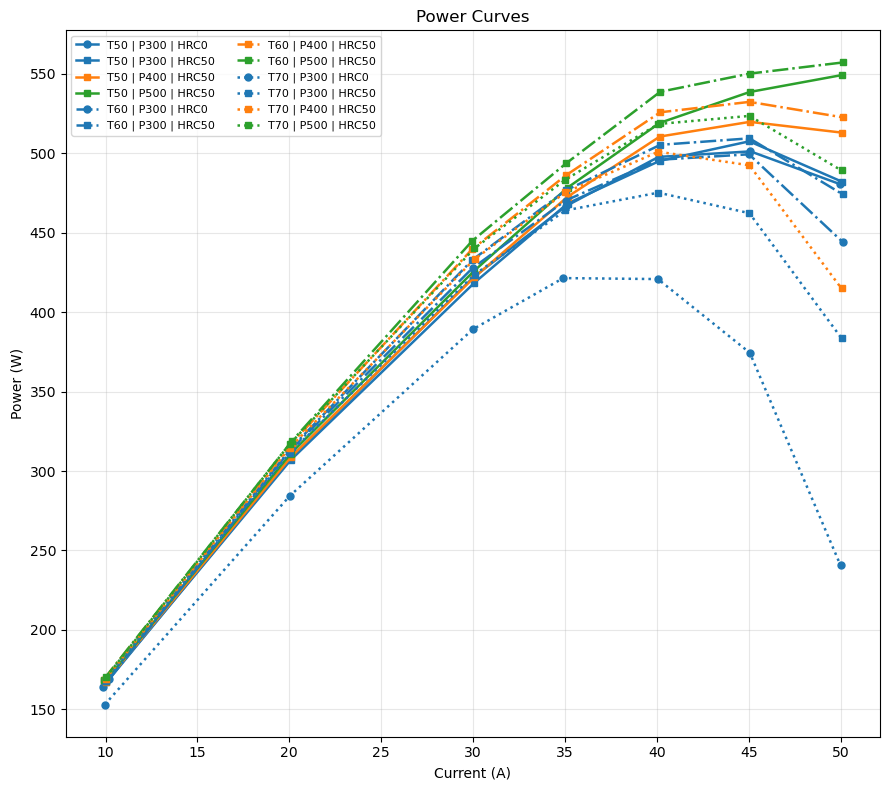

In [25]:
plt.figure(figsize=(9, 8))

for key, pola_data in polacurve_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    df["POWER"] = df["VFC"] * df["I_LOAD"]

    plt.plot(df["I_LOAD"],df["POWER"],
        linestyle=temp_linestyles.get(key_T, "-"),
        color=pressure_colors.get(key_P, "black"),
        marker=hrc_markers.get(key_HRC, "o"),
        linewidth=1.8,
        markersize=5,
        label=f"{key_T} | {key_P} | {key_HRC}",
    )

plt.xlabel("Current (A)")
plt.ylabel("Power (W)")
plt.title("Power Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

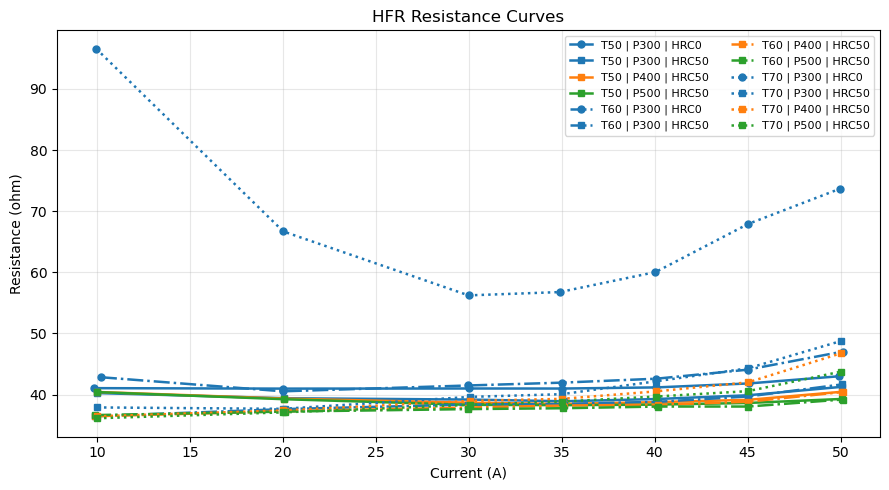

In [26]:
plt.figure(figsize=(9, 5))

for key, pola_data in hfr_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["R", "I_LOAD"]).sort_values("I_LOAD")

    plt.plot(
        df["I_LOAD"],
        df["R"],
        linestyle=temp_linestyles.get(key_T, "-"),
        color=pressure_colors.get(key_P, "black"),
        marker=hrc_markers.get(key_HRC, "o"),
        linewidth=1.8,
        markersize=5,
        label=f"{key_T} | {key_P} | {key_HRC}",
    )

plt.xlabel("Current (A)")
plt.ylabel("Resistance (ohm)")
plt.title("HFR Resistance Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

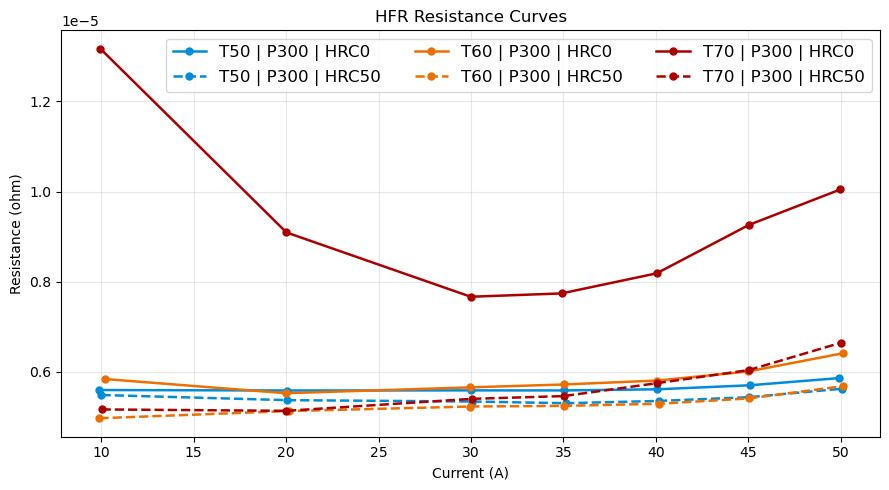

In [27]:
plt.figure(figsize=(9, 5))

temp_color = {"T50": "#008CD7", "T60": "#ED6F00", "T70": "#AB0000"}
HRC_linestyles = {"HRC0": "-", "HRC50": "--"}
for key, pola_data in hfr_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["R", "I_LOAD"]).sort_values("I_LOAD")
    if (key_P == "P300"):
        plt.plot(df["I_LOAD"],df["R"] * 30e-4 /1e3/ 22 , linestyle=HRC_linestyles.get(key_HRC, "-"), color=temp_color.get(key_T),
                      linewidth=1.8, markersize=5, label=f"{key_T} | {key_P} | {key_HRC}", marker = "o")
    else:
        continue

plt.xlabel("Current (A)")
plt.ylabel("Resistance (ohm)")
plt.title("HFR Resistance Curves")
plt.legend(ncol=3, fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

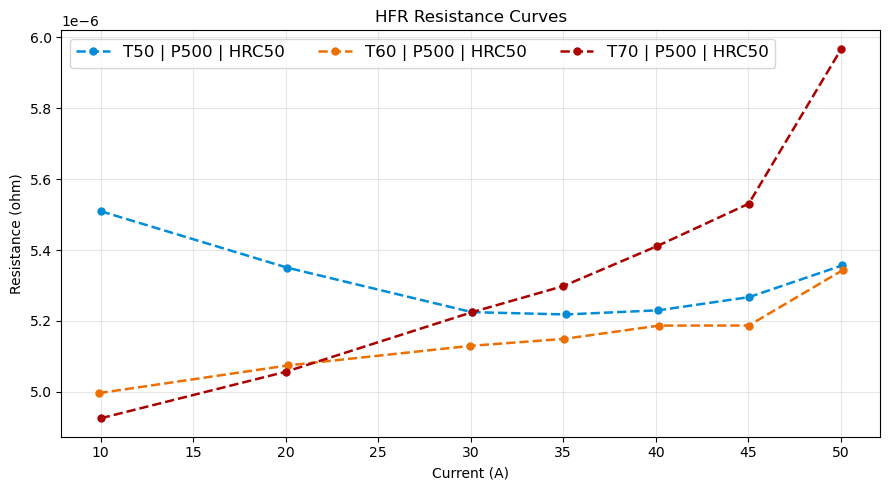

In [28]:
plt.figure(figsize=(9, 5))

temp_color = {"T50": "#008CD7", "T60": "#ED6F00", "T70": "#AB0000"}
HRC_linestyles = {"HRC0": "-", "HRC50": "--"}
for key, pola_data in hfr_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["R", "I_LOAD"]).sort_values("I_LOAD")
    if (key_P == "P500") and (key_HRC == "HRC50"):
        plt.plot(df["I_LOAD"],df["R"] * 30e-4 /1e3/ 22 , linestyle=HRC_linestyles.get(key_HRC, "-"), color=temp_color.get(key_T),
                      linewidth=1.8, markersize=5, label=f"{key_T} | {key_P} | {key_HRC}", marker = "o")
    else:
        continue

plt.xlabel("Current (A)")
plt.ylabel("Resistance (ohm)")
plt.title("HFR Resistance Curves")
plt.legend(ncol=3, fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

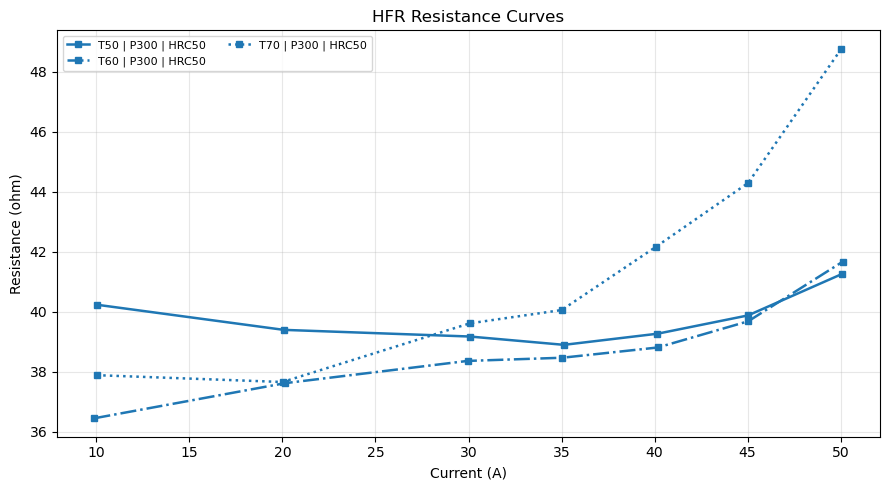

In [29]:
plt.figure(figsize=(9, 5))

for key, pola_data in hfr_sets.items():

    key_T, key_P, key_HRC = key.split("_")
    df = pd.DataFrame(pola_data, columns=["R", "I_LOAD"]).sort_values("I_LOAD")
    if (key_HRC == "HRC50" and key_P == "P300"):
        plt.plot(
            df["I_LOAD"],
            df["R"],
            linestyle=temp_linestyles.get(key_T, "-"),
            color=pressure_colors.get(key_P, "black"),
            marker=hrc_markers.get(key_HRC, "o"),
            linewidth=1.8,
            markersize=5,
            label=f"{key_T} | {key_P} | {key_HRC}",
        )
    else:
        continue

plt.xlabel("Current (A)")
plt.ylabel("Resistance (ohm)")
plt.title("HFR Resistance Curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
pola_output = "pola_data.xlsx"
hfr_output = "hfr_data.xlsx"

with pd.ExcelWriter(pola_output, engine="openpyxl") as writer:
    for condition in sorted(polacurve_sets.keys()):
        pola_points = polacurve_sets.get(condition, [])
        pola_df = pd.DataFrame(pola_points, columns=["VFC", "I_LOAD"])
        pola_df = pola_df.sort_values("I_LOAD").reset_index(drop=True)
        pola_df.to_excel(writer, sheet_name=condition, index=False)

with pd.ExcelWriter(hfr_output, engine="openpyxl") as writer:
    for condition in sorted(hfr_sets.keys()):
        current_vals = [point[1] for point in polacurve_sets.get(condition, [])]
        resistance_vals = hfr_sets.get(condition, [])
        n = min(len(current_vals), len(resistance_vals))

        hfr_df = pd.DataFrame(
            {
                "I_LOAD": current_vals[:n],
                "R": resistance_vals[:n],
            }
        ).sort_values("I_LOAD").reset_index(drop=True)

        hfr_df.to_excel(writer, sheet_name=condition, index=False)

print(f"Saved: {pola_output}")
print(f"Saved: {hfr_output}")

Saved: pola_data.xlsx
Saved: hfr_data.xlsx
